## Import 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from skorch import NeuralNetClassifier

In [3]:
# Load preprocessed data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

In [2]:
# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

## Weighted FFNN Model

In [4]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train['cleaned_text']).toarray()
X_test = vectorizer.transform(test['cleaned_text']).toarray()

In [5]:
# FFNN Model
# We chose a 3 layer model as LSTM has 3 gates
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
output_dim = len(label_encoder.classes_)

In [6]:
class_counts = Counter(y_train)
print(class_counts)

Counter({3: 920, 4: 305, 1: 244, 0: 162, 2: 148})


In [7]:
class_counts = torch.tensor([162, 244, 148, 920, 305], dtype=torch.float)
weights = 1. / class_counts
weights = weights / weights.sum() 

Weight normalization is used here to maintain a consistent overall scale. This prevents disproportionately large loss values for rare classes, which could lead to unstable or overly aggressive gradient updates. By normalizing the weights to sum to 1, the training process remains numerically stable while still emphasizing underrepresented classes.

In [8]:
# Wrap model for skorch
net = NeuralNetClassifier(
    FFNN,
    module__input_dim=input_dim,
    module__hidden_dim=256,
    module__output_dim=output_dim,
    max_epochs=10,
    lr=1e-3,
    optimizer=optim.Adam,
    criterion=nn.CrossEntropyLoss(weight=weights),
    batch_size=64,
    device=device
)

In [9]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=1.0, min_df=2, ngram_range=(1, 2))),
    ('net', net)
])

We fixed the TD-IDF parameters to the same hyper parameters obtained when tuning the decision tree for a fairer comparison between the models

In [10]:
# Grid search parameters
param_grid = {
    'module__hidden_dim': [128, 256, 512],
    'lr': [1e-3, 5e-4],
    'batch_size': [32, 64],
    'max_epochs': [5, 10]
}

In [11]:
grid = GridSearchCV(net, param_grid, scoring='f1_macro', cv=3, verbose=1)
grid.fit(X_train.astype(np.float32), y_train)

print("Best parameters found:")
print(grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.6098       0.2941        1.5970  0.5074
      2        1.5533       0.5966        1.5432  0.2503
      3        1.2902       0.6471        1.3783  0.2453
      4        0.7411       0.6134        1.2189  0.2880
      5        0.2887       0.6471        1.2376  0.2655
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.6080       0.5168        1.6008  0.2434
      2        1.5548       0.6303        1.5466  0.2442
      3        1.2902       0.6050        1.3599  0.2470
      4        0.7064       0.6050        1.1639  0.2425
      5        0.2667       0.6303        1.1013  0.2481
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.6073      

Best parameters found:
{'batch_size': 32, 'lr': 0.001, 'max_epochs': 5, 'module__hidden_dim': 128}

In [12]:
# Evaluate best model
best_model = grid.best_estimator_
preds = best_model.predict(X_test.astype(np.float32))
probs = best_model.predict_proba(X_test.astype(np.float32))

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
report = classification_report(y_test, preds, target_names=label_encoder.classes_)

print(f"FFNN Accuracy: {acc * 100:.2f}%")
print(f"FFNN Macro F1-score: {f1:.4f}")
print("\nClassification Report:\n", report)

FFNN Accuracy: 69.21%
FFNN Macro F1-score: 0.5775

Classification Report:
               precision    recall  f1-score   support

      center       0.81      0.42      0.56        40
   lean left       0.43      0.54      0.48        61
  lean right       0.40      0.32      0.36        37
        left       0.81      0.85      0.83       230
       right       0.66      0.66      0.66        77

    accuracy                           0.69       445
   macro avg       0.62      0.56      0.58       445
weighted avg       0.70      0.69      0.69       445



#### Classification Report Commentary

The FFNN outperforms all decision tree variants in overall accuracy, reaching 69.21% accuracy. However, the macro F1-score (0.5581) remains comparable to the tuned decision tree, indicating that class imbalance still impacts per-class fairness.


- The model performs very well on the majority class:
  - Left: F1 = 0.83
- It also performs reasonably well on a minority class:
  - Right: F1 = 0.66
- Other minority classes remain problematic:
	- Center: F1 = 0.56 
	- Lean left: F1 = 0.48
	- Lean right: F1 = 0.36 (lowest overall)

This shows that while the FFNN is effective overall, it continues to struggle with detecting minority class instances, especially lean right.

### Confusion Matrices

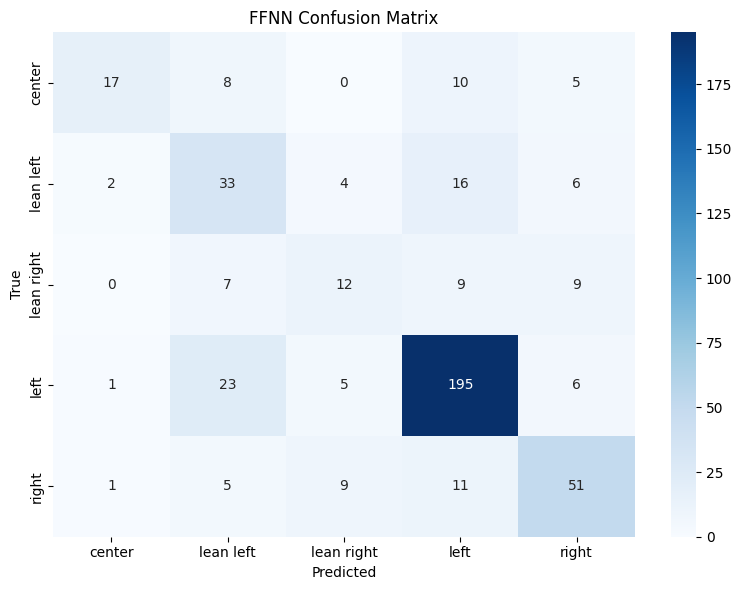

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('FFNN Confusion Matrix')
plt.tight_layout()
plt.show()


- The FFNN performs well on the “left” and “right” classes, with 195 and 51 correct predictions respectively, showing strong class identification on the extremes.
- There is still moderate confusion between neighboring classes like “lean left” and “left”, and between “lean right” and “right”, indicating room for improvement in boundary refinement.
- Compared to decision trees, the FFNN appears more balanced overall but struggles slightly with nuanced central categories like “lean right” and “center”.

### ROC-AUC

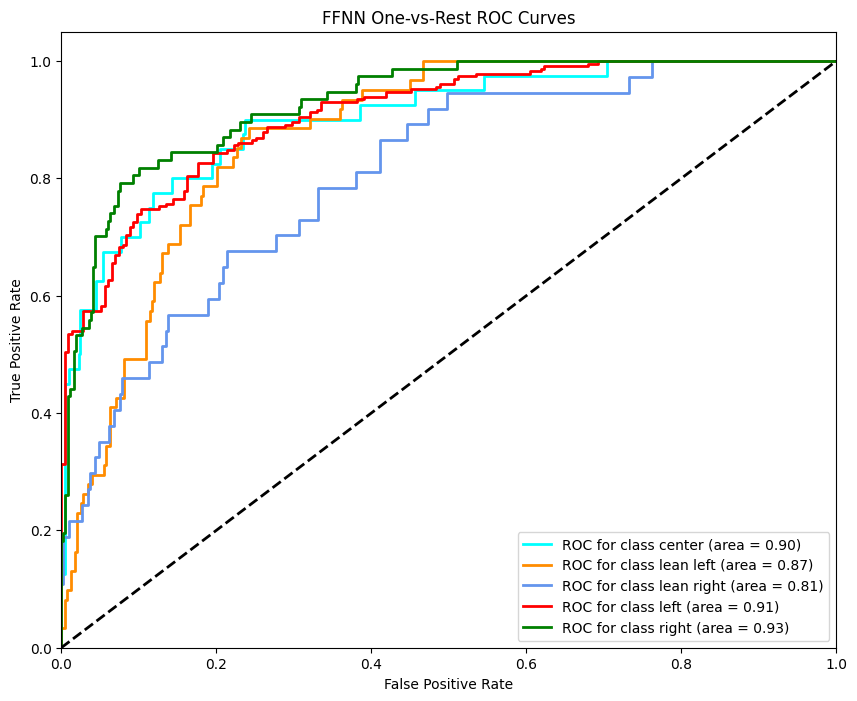

In [14]:
# ROC Curves
y_test_bin = label_binarize(y_test, classes=np.arange(output_dim))
probs = np.array(probs)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(output_dim):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], probs[:, i])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for i, color in zip(range(output_dim), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC for class {label_encoder.classes_[i]} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FFNN One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


ROC-AUC values are consistently strong across all classes:
- Center: 0.90  
- Lean Left: 0.87
- Lean Right: 0.81  
- Left: 0.91  
- Right: 0.93  

This suggests that the model has learned good decision boundaries for all classes, even if classification thresholds (affecting precision/recall) are not ideal for minority classes. The ROC curves reinforce that the model is well-calibrated, and further improvements may come from threshold tuning or cost-sensitive training.


## Final Conclusion

### Performance Metrics Evaluation Summary

| Model Version | Accuracy (%) | Macro F1-score |
|---------------|--------------|----------------|
| Unweighted DT | 65.84        | 0.5658         |
| Weighted DT   | 60.22        | 0.5209         |
| Tuned DT      | 57.53        | 0.5762         |
| Tuned FFNN    | 69.21        | 0.5775         |


### Final Remarks

> Overall, the FFNN provides the best performance among all models, with high accuracy and robust AUC across classes. However, it still underperforms on low-support categories. This confirms that neural networks outperform decision trees in raw performance, but still benefit from further balancing techniques (e.g., class weighting or data augmentation).